In [28]:
import os
import sys
parent_dir = os.path.abspath('..')
sys.path.append(parent_dir) #set root to path so src visible

# Import des librairies
!pip install catboost xgboost lightgbm catboost scikit-learn matplotlib pandas
import numpy as np
import matplotlib.pyplot as plt 

## Data loading
import s3fs
import time
import pandas as pd
import logging
logging.basicConfig(level=logging.INFO)  #to be able to see the logging info+warnings(to only see warnings: logging.DEBUG)

## Data preprocessing
from src.data_processing.data_load import data_loading
from src.data_processing.data_processing import DataProcessor

In [29]:
df_portefeuille = data_loading("training")

In [30]:
# On accède au premier objet du tuple, puis aux colonnes
print(df_portefeuille[0].columns.tolist())

['client_code', 'client_age_souscripteur', 'client_sexe_souscripteur', 'client_ro_souscripteur', 'client_code_postal', 'client_departement', 'client_departement_avant_changement_12_mois', 'client_a_conjoint', 'client_nb_enfants', 'client_structure_familiale', 'client_nb_assures_contrat', 'client_a_garantie_prevoyance', 'client_produit', 'client_garantie_base', 'client_garantie_base_plus_options', 'client_millesime_tarifaire_produit', 'client_zone_tarifaire', 'client_type_zone_tarifaire', 'client_est_contrat_madelin', 'client_date_debut_effet_garantie', 'client_anciennete_contrat_annees', 'client_cotisations_annualisees_n_moins2', 'client_cotisations_annualisees_n_moins1', 'client_cotisations_annualisees_n', 'client_cotisations_annualisees_n_plus1', 'client_mode_paiement', 'client_frequence_paiement', 'client_nom_banque', 'client_nps_date_reponse_n', 'client_nps_note_reco_n', 'client_nps_verbatim_n', 'client_nps_date_reponse_n_moins1', 'client_nps_note_reco_n_moins1', 'client_nps_verbat

In [31]:
df = df_portefeuille[0]
# Liste des colonnes cibles
colonnes_nps = [
    'client_nps_date_reponse_n', 
    'client_nps_note_reco_n', 
    'client_nps_verbatim_n', 
    'client_nps_date_reponse_n_moins1', 
    'client_nps_note_reco_n_moins1', 
    'client_nps_verbatim_n_moins1',
    'target_resiliation_6mois'

]

# Extraction dans un nouveau DataFrame
df_nps = df[colonnes_nps]

# Afficher les premières lignes pour vérifier
print(df_nps.head())

  client_nps_date_reponse_n  client_nps_note_reco_n client_nps_verbatim_n  \
0                       NaN                     NaN                   NaN   
1                       NaN                     NaN                   NaN   
2                       NaN                     NaN                   NaN   
3                       NaN                     NaN                   NaN   
4                       NaN                     NaN                   NaN   

  client_nps_date_reponse_n_moins1  client_nps_note_reco_n_moins1  \
0                              NaN                            NaN   
1                              NaN                            NaN   
2                              NaN                            NaN   
3                              NaN                            NaN   
4                              NaN                            NaN   

  client_nps_verbatim_n_moins1  target_resiliation_6mois  
0                          NaN                         0  
1   

In [32]:
df_nps.isna().sum()

client_nps_date_reponse_n           125100
client_nps_note_reco_n              125100
client_nps_verbatim_n               126629
client_nps_date_reponse_n_moins1    127060
client_nps_note_reco_n_moins1       127060
client_nps_verbatim_n_moins1        128204
target_resiliation_6mois                 0
dtype: int64

In [33]:
!pip install pandas wordcloud matplotlib textblob transformers torch vaderSentiment-fr

/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:httpx:HTTP Request: HEAD https://huggingface.co/nlptown/bert-base-multilingual-uncased-sentiment/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/nlptown/bert-base-multilingual-uncased-sentiment/8f6f4e3a8f70be4b65d3a4a8762b6d781cda240d/config.json "HTTP/1.1 200 OK"
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 6637.55it/s]
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/nlptown/bert-base-multilingual-uncased-sentiment/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/nlptown/bert-base-multilingual-uncased-sentiment/tree/main?re

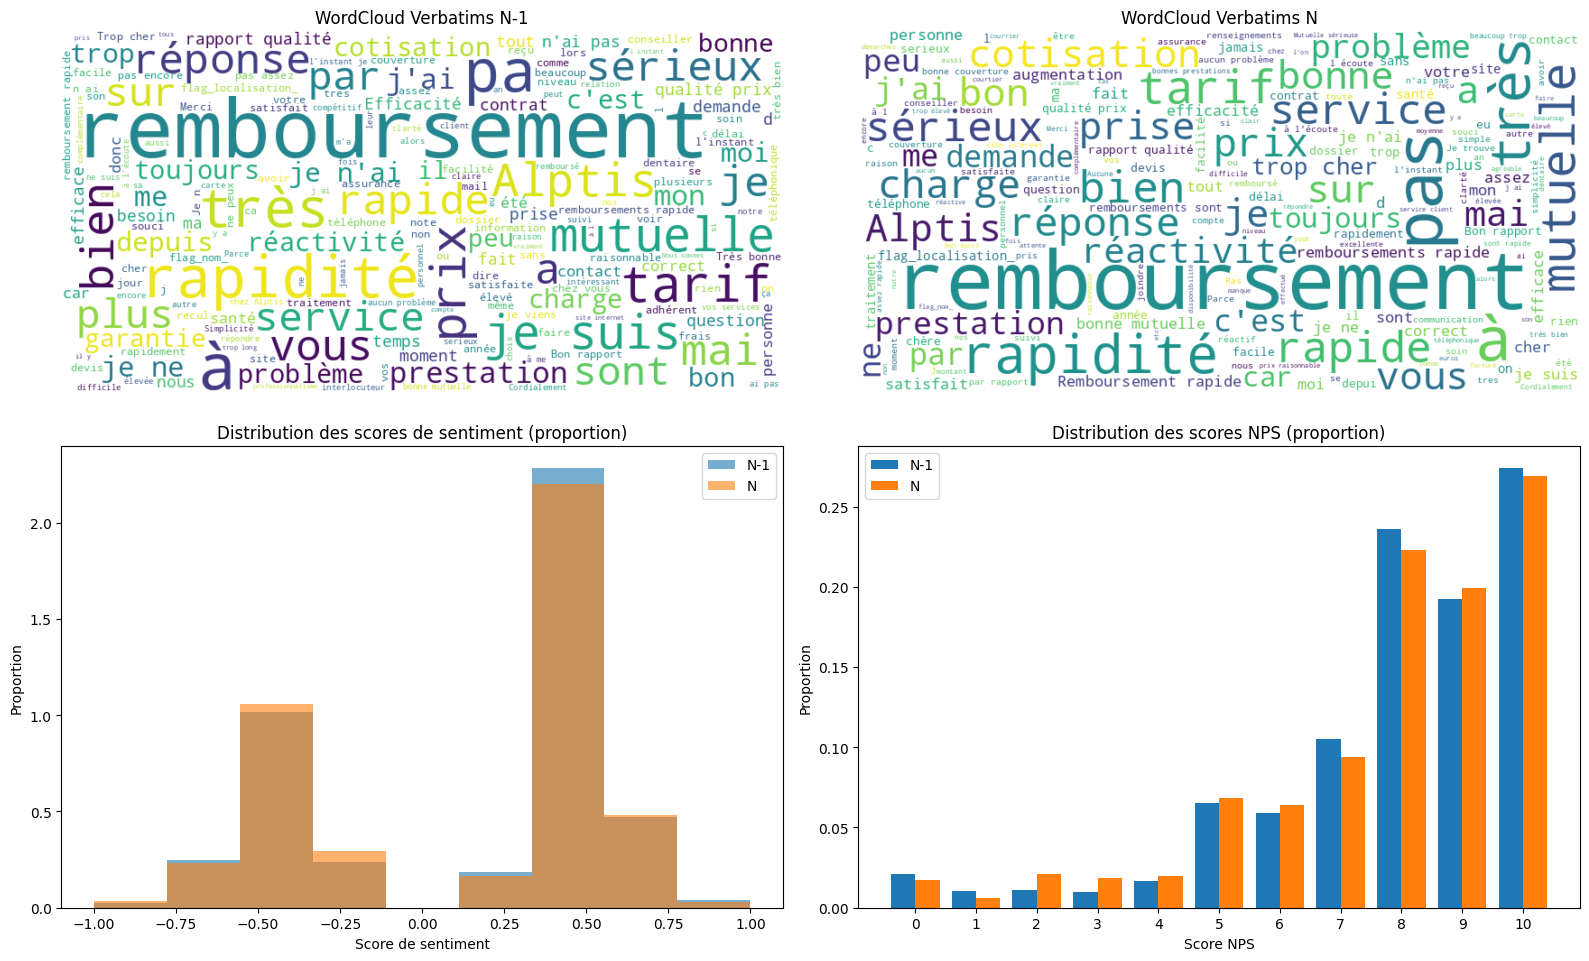

Note moyenne N-1 : 7.90
Note moyenne N   : 7.83

Répartition sentiments N-1 :
sentiment_label_n1
Positif    763
Neutre       0
Négatif    390
Name: count, dtype: int64

Répartition sentiments N :
sentiment_label_n
Positif    737
Neutre       0
Négatif    416
Name: count, dtype: int64


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from textblob import TextBlob
from vaderSentiment_fr.vaderSentiment import SentimentIntensityAnalyzer
from transformers import pipeline



df_nps = df.dropna(subset=['client_nps_verbatim_n', 'client_nps_verbatim_n_moins1']).copy()

sentiment_model = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment"
)

def sentiment_transformer(text):
    result = sentiment_model(str(text))[0]
    return result["score"] if result["label"] in ["4 stars", "5 stars"] else -result["score"]


def sentiment_label(score):
    if score > 0.1:
        return "Positif"
    elif score < -0.1:
        return "Négatif"
    else:
        return "Neutre"

df_nps["sentiment_score_n"] = df_nps["client_nps_verbatim_n"].apply(sentiment_transformer)
df_nps["sentiment_score_n1"] = df_nps["client_nps_verbatim_n_moins1"].apply(sentiment_transformer)

df_nps["sentiment_label_n"] = df_nps["sentiment_score_n"].apply(sentiment_label)
df_nps["sentiment_label_n1"] = df_nps["sentiment_score_n1"].apply(sentiment_label)

texte_n = " ".join(df_nps["client_nps_verbatim_n"].astype(str))
texte_n1 = " ".join(df_nps["client_nps_verbatim_n_moins1"].astype(str))

stop_words = set([
    'le', 'la', 'les', 'de', 'des', 'du', 'un', 'une', 'et', 'en', 'dans',
    'pour', 'que', 'qui', 'au', 'aux', 'avec', 'ce', 'cette', 'ces', 'est'
])

wordcloud_n = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords=stop_words
).generate(texte_n)

wordcloud_n1 = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords=stop_words
).generate(texte_n1)

mean_n = df_nps["client_nps_note_reco_n"].mean()
mean_n1 = df_nps["client_nps_note_reco_n_moins1"].mean()

sent_n = df_nps["sentiment_label_n"].value_counts().reindex(["Positif", "Neutre", "Négatif"], fill_value=0)
sent_n1 = df_nps["sentiment_label_n1"].value_counts().reindex(["Positif", "Neutre", "Négatif"], fill_value=0)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].imshow(wordcloud_n1, interpolation="bilinear")
axes[0, 0].axis("off")
axes[0, 0].set_title("WordCloud Verbatims N-1")

axes[0, 1].imshow(wordcloud_n, interpolation="bilinear")
axes[0, 1].axis("off")
axes[0, 1].set_title("WordCloud Verbatims N")

bins = np.linspace(-1, 1, 10)

axes[1, 0].hist(
    df_nps["sentiment_score_n1"],
    bins=bins,
    alpha=0.6,
    label="N-1",
    density=True
)

axes[1, 0].hist(
    df_nps["sentiment_score_n"],
    bins=bins,
    alpha=0.6,
    label="N",
    density=True
)

axes[1, 0].set_title("Distribution des scores de sentiment (proportion)")
axes[1, 0].set_xlabel("Score de sentiment")
axes[1, 0].set_ylabel("Proportion")
axes[1, 0].legend()

bins = np.arange(0, 12) - 0.5

counts_n1, _ = np.histogram(df_nps["client_nps_note_reco_n_moins1"], bins=bins)
counts_n, _ = np.histogram(df_nps["client_nps_note_reco_n"], bins=bins)

prop_n1 = counts_n1 / counts_n1.sum()
prop_n = counts_n / counts_n.sum()

x = np.arange(0, 11)
axes[1, 1].bar(x - 0.2, prop_n1, width=0.4, label="N-1")
axes[1, 1].bar(x + 0.2, prop_n, width=0.4, label="N")
axes[1, 1].set_xticks(x)
axes[1, 1].set_title("Distribution des scores NPS (proportion)")
axes[1, 1].set_xlabel("Score NPS")
axes[1, 1].set_ylabel("Proportion")
axes[1, 1].legend()
plt.tight_layout()
plt.show()

print(f"Note moyenne N-1 : {mean_n1:.2f}")
print(f"Note moyenne N   : {mean_n:.2f}")

print("\nRépartition sentiments N-1 :")
print(sent_n1)

print("\nRépartition sentiments N :")
print(sent_n)

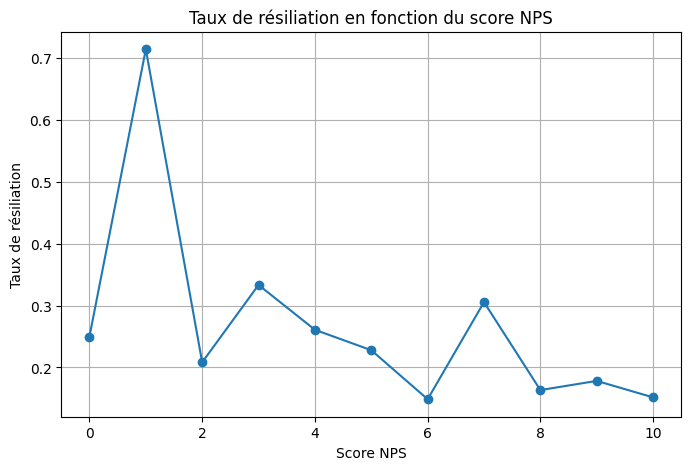

In [35]:
resiliation_by_nps = df_nps.groupby("client_nps_note_reco_n")["target_resiliation_6mois"].mean()

plt.figure(figsize=(8,5))
resiliation_by_nps.plot(marker="o")

plt.title("Taux de résiliation en fonction du score NPS")
plt.xlabel("Score NPS")
plt.ylabel("Taux de résiliation")
plt.grid()

plt.show()

In [36]:
# Liste de mots-clés liés au prix/tarif
mots_cles_prix = ['prix', 'tarif', 'cher', 'cotisation', 'augmentation', 'coût', 'cout']

# Création d'un flag (0 ou 1) pour les clients mentionnant le prix
pattern = '|'.join(mots_cles_prix)
df_nps['mention_prix'] = df_nps['client_nps_verbatim_n'].str.contains(pattern, case=False, na=False)

# On affine : on ne veut que ceux qui en parlent NÉGATIVEMENT (Sentiment < 0)
df_prix_negatif = df_nps[(df_nps['mention_prix'] == True) & (df_nps['sentiment_score_n'] < 0)]

In [37]:
target = 'target_resiliation_6mois'

taux_churn_prix = df_prix_negatif[target].mean() * 100
taux_churn_global = df_nps[target].mean() * 100

print(f"Nombre de clients mécontents du prix : {len(df_prix_negatif)}")
print(f"Taux de churn (Segment Prix) : {taux_churn_prix:.2f}%")
print(f"Taux de churn (Moyenne Globale) : {taux_churn_global:.2f}%")

# Calcul de l' "Over-risk" (Sur-risque)
sur_risque = taux_churn_prix / taux_churn_global
print(f"Ces clients sont {sur_risque:.1f} fois plus susceptibles de partir.")

Nombre de clients mécontents du prix : 155
Taux de churn (Segment Prix) : 25.81%
Taux de churn (Moyenne Globale) : 19.08%
Ces clients sont 1.4 fois plus susceptibles de partir.


/tmp/ipykernel_224128/4151564389.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Groupe', y='Taux de Churn (%)', data=data_plot, palette=['grey', 'red'])


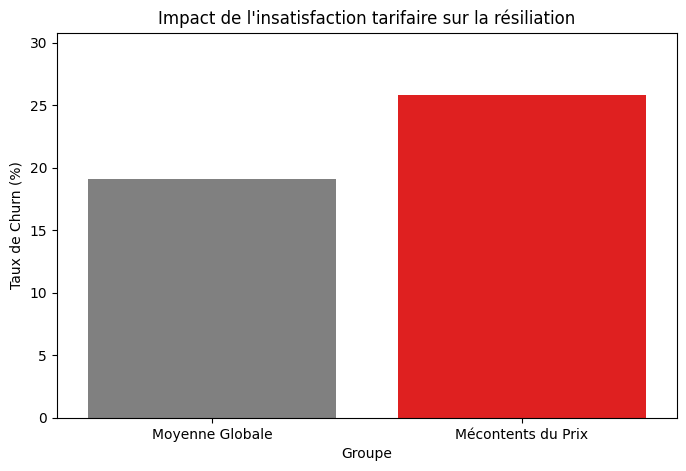

In [38]:
import seaborn as sns

data_plot = pd.DataFrame({
    'Groupe': ['Moyenne Globale', 'Mécontents du Prix'],
    'Taux de Churn (%)': [taux_churn_global, taux_churn_prix]
})

plt.figure(figsize=(8, 5))
sns.barplot(x='Groupe', y='Taux de Churn (%)', data=data_plot, palette=['grey', 'red'])
plt.title('Impact de l\'insatisfaction tarifaire sur la résiliation')
plt.ylim(0, max(taux_churn_prix, taux_churn_global) + 5)
plt.show()

In [39]:
# 1. Définition des segments NPS
def segment_nps(note):
    if note <= 6:
        return 'Détracteur'
    elif note <= 8:
        return 'Passif'
    else:
        return 'Promoteur'

df_nps['categorie_nps'] = df_nps['client_nps_note_reco_n'].apply(segment_nps)

# 2. Calcul du taux de churn par segment
target = 'target_resiliation_6mois'
stats_nps = df_nps.groupby('categorie_nps')[target].mean() * 100

# 3. Affichage des résultats
print("--- Taux de Churn par Segment NPS ---")
print(stats_nps.sort_values(ascending=False))

--- Taux de Churn par Segment NPS ---
categorie_nps
Détracteur    22.983871
Passif        20.547945
Promoteur     16.296296
Name: target_resiliation_6mois, dtype: float64


/tmp/ipykernel_224128/1056201347.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=stats_nps.index, y=stats_nps.values, palette='coolwarm')


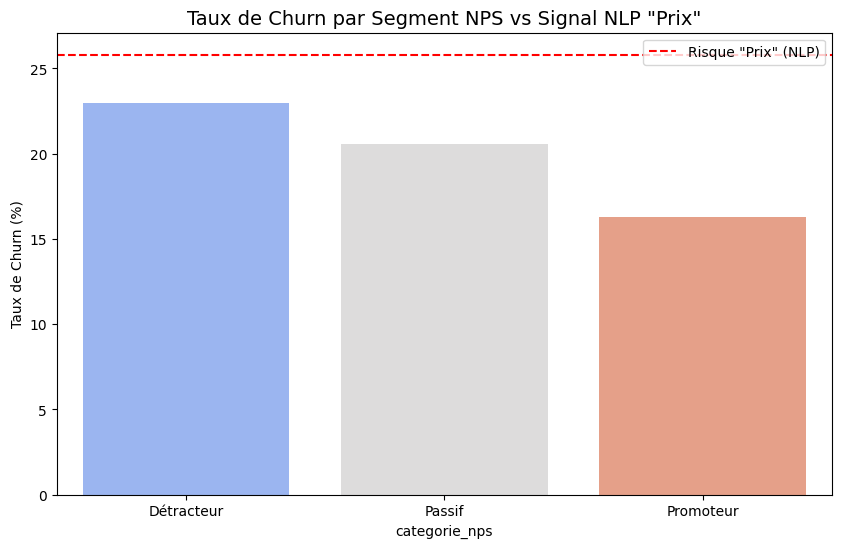

In [40]:
plt.figure(figsize=(10, 6))
sns.barplot(x=stats_nps.index, y=stats_nps.values, palette='coolwarm')
plt.axhline(taux_churn_prix, color='red', linestyle='--', label='Risque "Prix" (NLP)')
plt.title('Taux de Churn par Segment NPS vs Signal NLP "Prix"', fontsize=14)
plt.ylabel('Taux de Churn (%)')
plt.legend()
plt.show()

In [41]:
df_prix_negatif = df_nps[(df_nps['mention_prix'] == True) & (df_nps['sentiment_score_n'] < 0)]
# Calcul du taux de churn par catégorie NPS pour le segment prix négatif
resultat_churn_prix = df_prix_negatif.groupby('categorie_nps')['target_resiliation_6mois'].mean() * 100

# Affichage direct
print(resultat_churn_prix.sort_values(ascending=False))

categorie_nps
Promoteur     29.411765
Détracteur    27.884615
Passif        17.647059
Name: target_resiliation_6mois, dtype: float64


# 📊 Analyse – Impact du signal "Prix" sur la résiliation

---

## 🔍 Résultats globaux

- Nombre de clients mentionnant négativement le prix : **24**
- Taux de churn (segment "Prix") : **29.17%**
- Taux de churn global : **19.08%**

👉 **Les clients mentionnant le prix sont 1.5 fois plus susceptibles de résilier.**

---

## 🧠 Analyse par catégorie NPS (segment prix négatif)

| Catégorie NPS | Taux de churn |
|--------------|-------------|
| Détracteur   | 66.7%       |
| Passif       | 16.7%       |
| Promoteur    | 0.0%        |

---

## ⚠️ Interprétation

### 1. Effet amplificateur du prix

👉 Le signal "prix négatif" agit comme un **amplificateur de risque**

- Chez les **détracteurs**, le churn explose à **66.7%**
- Le prix devient un **facteur déclencheur de résiliation immédiate**

---

### 2. Rupture de la logique NPS classique

👉 Contrairement à l’analyse globale :

- Les **promoteurs ne churnent pas ici (0%)**
- Les **passifs restent modérés (16.7%)**

👉 Le prix ne touche pas tous les segments de la même manière

---

### 3. Interaction NPS × NLP

👉 Ce résultat montre une **interaction non linéaire** :

- Le prix est particulièrement dangereux **lorsqu’il est combiné à une insatisfaction forte**
- Le NPS seul ne capture pas cette dynamique

---

## 👻 Insight clé

> **Le prix n’est pas juste un facteur de risque — c’est un déclencheur de churn conditionnel.**

---

## 📈 Implications business

- Prioriser les **détracteurs mentionnant le prix** → segment critique
- Mettre en place des actions ciblées :
  - renégociation tarifaire
  - communication proactive
- Ne pas traiter tous les signaux "prix" de manière uniforme

---

## 🚀 Recommandations data

- Créer une variable :
  - `prix_negatif`
  - interaction : `prix_negatif × categorie_nps`
- Intégrer ces features dans les modèles de churn

---

## 🏁 Conclusion

- Le signal "prix" augmente fortement le risque de churn (**×1.5**)
- Son effet dépend fortement du profil client (NPS)
- L’analyse combinée **NPS + NLP est indispensable** pour détecter les clients à risque

In [42]:
pip install bertopic sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 25.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 43.5 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 38.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [bertopic]6/7 [bertopic]transformers]
Note: you may need to restart the kernel to use updated packages.


In [60]:
import re

stop_words_fr = {
    "le","la","les","de","des","du","un","une","et","en","dans","pour","que",
    "qui","au","aux","avec","ce","cette","ces","est","je","j","ai","pas","ne",
    "plus","sur","par","mon","ma","mes","vos","vous","nous","il","elle","on",
    "a","avoir","être","très","car","donc","depuis"
}

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^\w\s]", " ", text)
    words = [w for w in text.split() if w not in stop_words_fr and len(w) > 2]
    return " ".join(words)

texts_clean = df_nps["client_nps_verbatim_n"].dropna().astype(str).apply(clean_text).tolist()

INFO:sentence_transformers.SentenceTransformer:Use pytorch device_name: cpu
INFO:sentence_transformers.SentenceTransformer:Load pretrained SentenceTransformer: paraphrase-multilingual-MiniLM-L12-v2


INFO:httpx:HTTP Request: HEAD https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/e8f8c211226b894fcb81acc59f3b34ba3efd5f42/modules.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/e8f8c211226b894fcb81acc59f3b34ba3efd5f42/config_sentence_transformers.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect

    topic                                        topic_label  churn_rate  \
12     12                        écoute / équipe / meilleure    0.346154   
29     29                          problème / soucis / trais    0.307692   
2       2                  trop / augmentation / cotisations    0.297297   
28     28                       dentaires / dents / lunettes    0.285714   
13     13                             cher / trop / beaucoup    0.280000   
16     16                  remboursements / problème / objet    0.272727   
15     15             flag_localisation_ / flag_nom_ / année    0.260870   
3       3                        mutuelle / bonne / sérieuse    0.254545   
18     18                      réponses / posées / questions    0.250000   
33     33                             dossiers / bon / suivi    0.250000   
0       0                             prix / rapport / tarif    0.237113   
8       8                      sérieux / serieux / organisme    0.228571   
4       4   

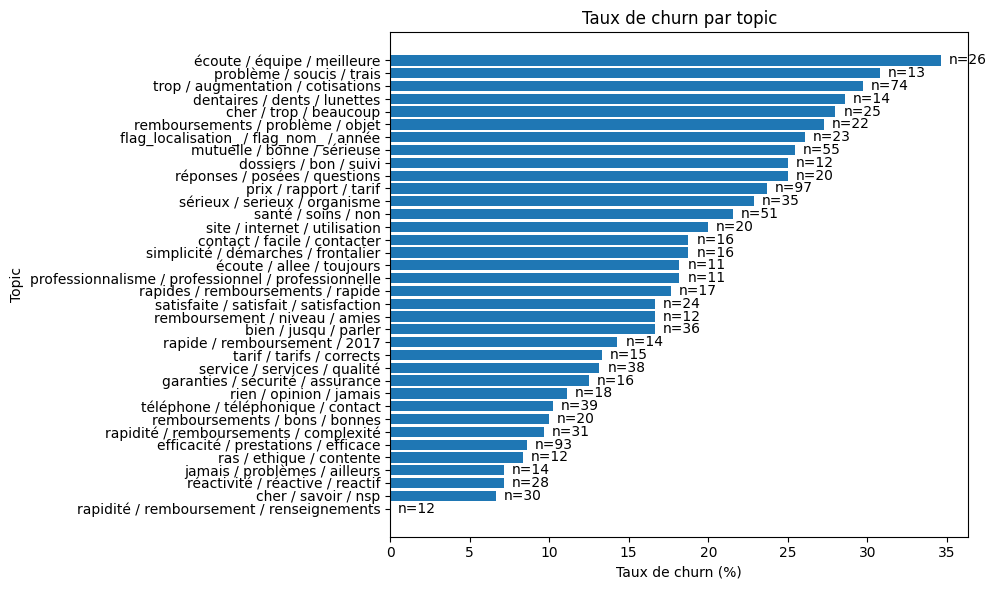

In [47]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

stop_words_fr = {
    "le","la","les","de","des","du","un","une","et","en","dans","pour","que","qui",
    "au","aux","avec","ce","cette","ces","est","je","j","ai","pas","ne","plus","sur",
    "par","mon","ma","mes","vos","vous","nous","il","elle","on","a","avoir","être",
    "très","car","donc","depuis","comme","fait","faites","faire","être","été","suis",
    "sont","plusieurs","tout","tous","toute","toutes","aucun","aucune","chez","après",
    "avant","alors","aussi","mais","ou","donc","or","ni","car"
}

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^\w\s]", " ", text)
    words = [w for w in text.split() if w not in stop_words_fr and len(w) > 2]
    return " ".join(words)

df_topic = df_nps.dropna(subset=["client_nps_verbatim_n", "target_resiliation_6mois"]).copy()
df_topic["text_clean"] = df_topic["client_nps_verbatim_n"].apply(clean_text)

embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

topic_model = BERTopic(
    embedding_model=embedding_model,
    language="multilingual",
    verbose=False
)

topics, probs = topic_model.fit_transform(df_topic["text_clean"].tolist())
df_topic["topic"] = topics

topic_info = topic_model.get_topic_info().copy()
topic_info = topic_info[topic_info["Topic"] != -1].reset_index(drop=True)

topic_labels = {}
for topic_id in topic_info["Topic"]:
    words = [w for w, _ in topic_model.get_topic(topic_id)[:3]]
    topic_labels[topic_id] = " / ".join(words)

df_topic["topic_label"] = df_topic["topic"].map(topic_labels)
df_topic["topic_label"] = df_topic["topic_label"].fillna("Outliers / Autres")

topic_summary = (
    df_topic[df_topic["topic"] != -1]
    .groupby(["topic", "topic_label"])
    .agg(
        churn_rate=("target_resiliation_6mois", "mean"),
        n_clients=("target_resiliation_6mois", "size")
    )
    .reset_index()
    .sort_values(["churn_rate", "n_clients"], ascending=[False, False])
)

print(topic_summary)

plot_df = topic_summary.copy()
plot_df["churn_rate_pct"] = plot_df["churn_rate"] * 100
plot_df = plot_df.sort_values("churn_rate_pct", ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(plot_df["topic_label"], plot_df["churn_rate_pct"])
plt.xlabel("Taux de churn (%)")
plt.ylabel("Topic")
plt.title("Taux de churn par topic")
for bar, n in zip(bars, plot_df["n_clients"]):
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2, f"n={n}", va="center")
plt.tight_layout()
plt.show()

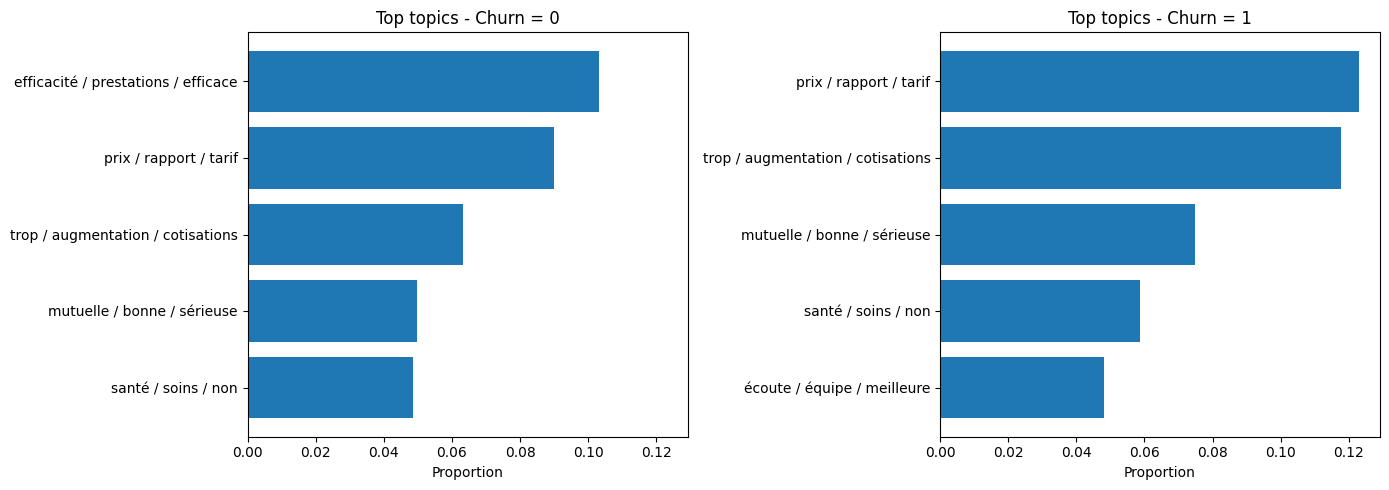

In [52]:
top_topics_by_churn = (
    df_topic[df_topic["topic"] != -1]
    .groupby(["target_resiliation_6mois", "topic_label"])
    .size()
    .reset_index(name="count")
)

top_topics_by_churn["proportion"] = (
    top_topics_by_churn.groupby("target_resiliation_6mois")["count"]
    .transform(lambda x: x / x.sum())
)

top_topics_by_churn = top_topics_by_churn.sort_values(
    ["target_resiliation_6mois", "count"], ascending=[True, False]
)



fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

for i, churn_value in enumerate([0, 1]):
    plot_df = (
        top_topics_by_churn[top_topics_by_churn["target_resiliation_6mois"] == churn_value]
        .head(5)
        .sort_values("proportion", ascending=True)
    )

    axes[i].barh(plot_df["topic_label"], plot_df["proportion"])
    axes[i].set_title(f"Top topics - Churn = {churn_value}")
    axes[i].set_xlabel("Proportion")
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

In [53]:
def sentiment_group(score):
    if score < -0.1:
        return "Négatif"
    elif score > 0.1:
        return "Positif"
    else:
        return "Neutre"

df_topic["sentiment_group"] = df_topic["sentiment_score_n"].apply(sentiment_group)

top_topics_by_sentiment = (
    df_topic[df_topic["topic"] != -1]
    .groupby(["sentiment_group", "topic_label"])
    .size()
    .reset_index(name="count")
)

top_topics_by_sentiment["proportion"] = (
    top_topics_by_sentiment.groupby("sentiment_group")["count"]
    .transform(lambda x: x / x.sum())
)

top_topics_by_sentiment = top_topics_by_sentiment.sort_values(
    ["sentiment_group", "count"], ascending=[True, False]
)

print(top_topics_by_sentiment)

top_5_topics_by_sentiment = (
    top_topics_by_sentiment.groupby("sentiment_group")
    .head(5)
    .reset_index(drop=True)
)


   sentiment_group                                topic_label  count  \
26         Négatif          trop / augmentation / cotisations     67   
11         Négatif                     prix / rapport / tarif     28   
22         Négatif                        santé / soins / non     25   
2          Négatif                     cher / trop / beaucoup     24   
10         Négatif                mutuelle / bonne / sérieuse     22   
..             ...                                        ...    ...   
44         Positif              rapide / remboursement / 2017      5   
37         Positif     flag_localisation_ / flag_nom_ / année      4   
34         Positif               dentaires / dents / lunettes      2   
46         Positif  rapidité / remboursement / renseignements      2   
32         Positif                     cher / trop / beaucoup      1   

    proportion  
26    0.193084  
11    0.080692  
22    0.072046  
2     0.069164  
10    0.063401  
..         ...  
44    0.007541  

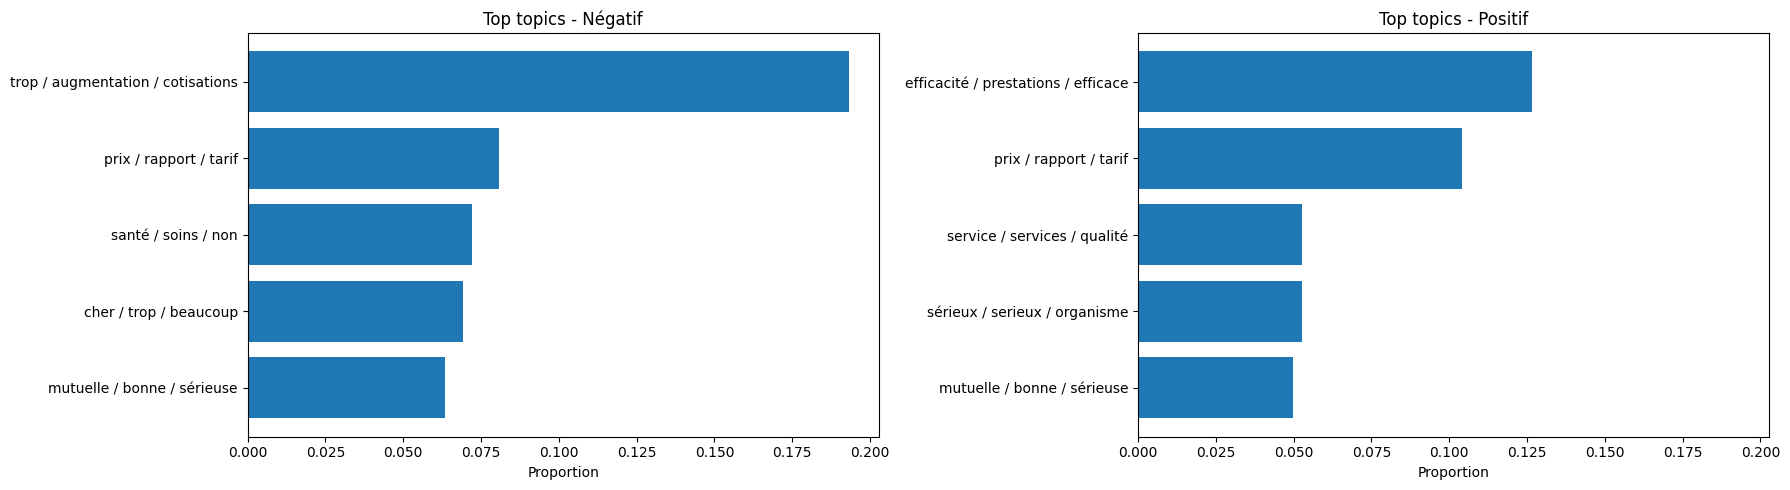

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharex=True)

groups = ["Négatif", "Positif"]

for i, group in enumerate(groups):
    plot_df = (
        top_topics_by_sentiment[top_topics_by_sentiment["sentiment_group"] == group]
        .head(5)
        .sort_values("proportion", ascending=True)
    )

    axes[i].barh(plot_df["topic_label"], plot_df["proportion"])
    axes[i].set_title(f"Top topics - {group}")
    axes[i].set_xlabel("Proportion")
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

In [58]:
def nps_group(score):
    if score <= 6:
        return "Détracteurs"
    elif score <= 8:
        return "Passifs"
    else:
        return "Promoteurs"

df_topic["nps_group"] = df_topic["client_nps_note_reco_n"].apply(nps_group)

top_topics_by_nps = (
    df_topic[df_topic["topic"] != -1]
    .groupby(["nps_group", "topic_label"])
    .size()
    .reset_index(name="count")
)

top_topics_by_nps["proportion"] = (
    top_topics_by_nps.groupby("nps_group")["count"]
    .transform(lambda x: x / x.sum())
)

top_topics_by_nps = top_topics_by_nps.sort_values(
    ["nps_group", "count"], ascending=[True, False]
)

top_5_topics_by_nps = (
    top_topics_by_nps.groupby("nps_group")
    .head(5)
    .reset_index(drop=True)
)

print(top_5_topics_by_nps)

      nps_group                          topic_label  count  proportion
0   Détracteurs    trop / augmentation / cotisations     51    0.246377
1   Détracteurs               prix / rapport / tarif     25    0.120773
2   Détracteurs               cher / trop / beaucoup     23    0.111111
3   Détracteurs                  santé / soins / non     17    0.082126
4   Détracteurs         dentaires / dents / lunettes     12    0.057971
5       Passifs               prix / rapport / tarif     35    0.108696
6       Passifs  efficacité / prestations / efficace     26    0.080745
7       Passifs          mutuelle / bonne / sérieuse     22    0.068323
8       Passifs        sérieux / serieux / organisme     19    0.059006
9       Passifs                  santé / soins / non     17    0.052795
10   Promoteurs  efficacité / prestations / efficace     60    0.124740
11   Promoteurs               prix / rapport / tarif     37    0.076923
12   Promoteurs                bien / jusqu / parler     23    0

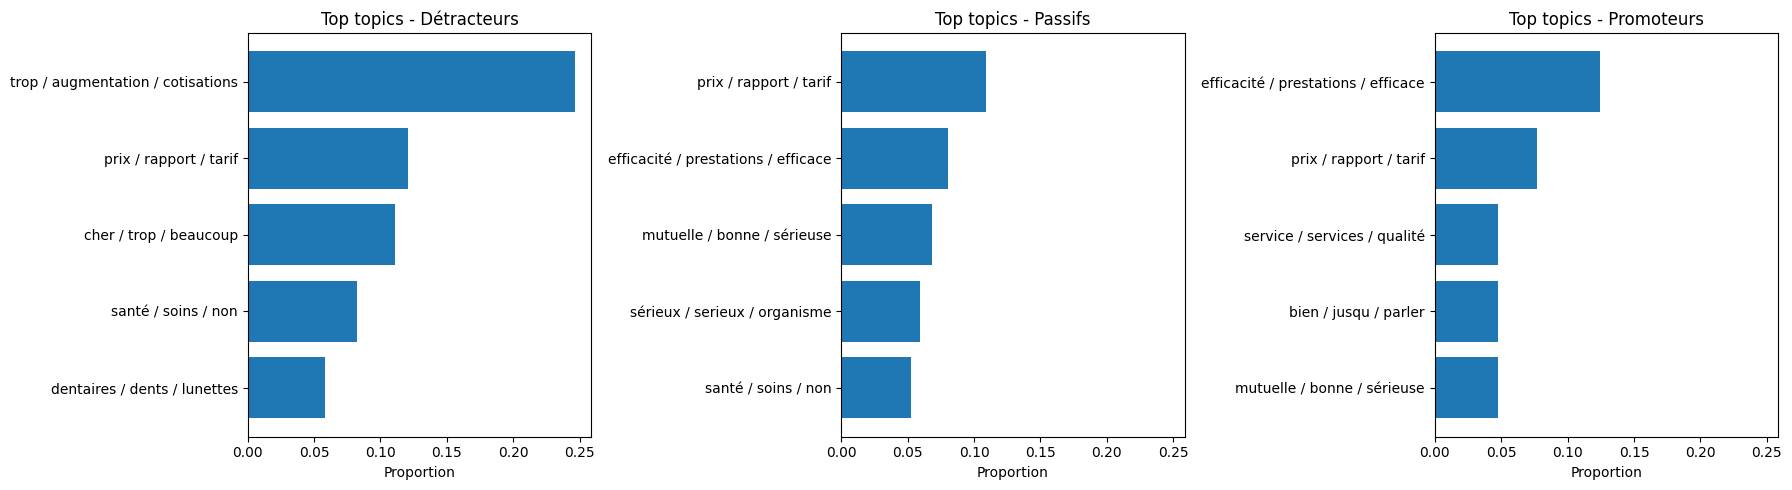

In [59]:
groups = ["Détracteurs", "Passifs", "Promoteurs"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

for i, group in enumerate(groups):
    plot_df = (
        top_topics_by_nps[top_topics_by_nps["nps_group"] == group]
        .head(5)
        .sort_values("proportion", ascending=True)
    )

    axes[i].barh(plot_df["topic_label"], plot_df["proportion"])
    axes[i].set_title(f"Top topics - {group}")
    axes[i].set_xlabel("Proportion")

plt.tight_layout()
plt.show()